<a href="https://colab.research.google.com/github/Kovibordy/ML-2.0/blob/main/%D0%BB%D0%B0%D0%B11_%D0%B3%D0%BE%D1%82%D0%BE%D0%B2%D0%BE%D0%B5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Решение задачи классификации и регрессии на основе многослойного перцептрона

### Вариант - 11

In [75]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Dropout
from tensorflow.keras.regularizers import L2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.regularizers import L2
from tensorflow.keras.utils import set_random_seed
from tensorflow.keras.callbacks import EarlyStopping

Фиксация случайности

In [76]:
SEED = 11
set_random_seed(SEED)

Загружаем данные для классификации

In [77]:
df_class = pd.read_csv('classify11.csv')
print(df_class.head())

         F1        F2        F3        F4  Target
0 -3.402839  0.179845  1.432424  0.774566       1
1 -1.902995 -1.241501  1.956614  0.512447       1
2 -1.023094  1.270126  0.782203 -0.785725       0
3 -0.331077 -0.069590 -0.258279 -0.339054       0
4 -3.377452  0.816699 -3.009166 -1.553258       2


Загружаем данные для регресии

In [78]:
df_reg = pd.read_csv('regress11.csv')
print(df_reg.head())

         V1        V2        V3        V4      Target
0 -0.919424  0.473592 -1.062304  1.549934   75.609515
1 -0.321635 -0.349258 -0.348652  2.076748  112.863277
2 -2.123896 -0.599393 -0.839722 -0.525755  322.077288
3 -1.070892 -0.857158  0.625667  0.482472  189.972784
4 -0.082151  1.443765 -1.251539  1.117296  197.191068


## Предобработка данных

In [79]:
def preprocess_data(df, target_col, test_size=0.2, random_state=SEED, is_classification=False):
    X = df.drop(columns=[target_col]).values
    y = df[target_col].values

    # Масштабирование признаков
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Разделение на train и test
    if is_classification:
        X_train, X_test, y_train, y_test = train_test_split(
            X_scaled, y, test_size=test_size, random_state=random_state, stratify=y
        )
    else:
        X_train, X_test, y_train, y_test = train_test_split(
            X_scaled, y, test_size=test_size, random_state=random_state
        )
    return X_train, X_test, y_train, y_test, scaler

X_train_cls, X_test_cls, y_train_cls, y_test_cls, scaler_cls = preprocess_data(df_class, 'Target', is_classification=True)
X_train_reg, X_test_reg, y_train_reg, y_test_reg, scaler_reg = preprocess_data(df_reg, 'Target', is_classification=False)

In [80]:
print(f"Регрессия: Train {X_train_reg.shape}, Test {X_test_reg.shape}")

Регрессия: Train (240, 4), Test (60, 4)


## Построение MLP для классификации

Будем использовать 3 нейрона

In [81]:
def create_classification_model(input_dim, num_classes=3):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['sparse_categorical_accuracy'])
    return model

model_cls = create_classification_model(X_train_cls.shape[1])
model_cls.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,499 (9.76 KB)

 Trainable params: 2,499 (9.76 KB)

 Non-trainable params: 0 (0.00 B)

In [82]:
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

history_cls = model_cls.fit(
    X_train_cls, y_train_cls,
    validation_split=0.2,
    epochs=200,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 1.0611 - sparse_categorical_accuracy: 0.4297 - val_loss: 1.0734 - val_sparse_categorical_accuracy: 0.3438
Epoch 2/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.9686 - sparse_categorical_accuracy: 0.5469 - val_loss: 0.9771 - val_sparse_categorical_accuracy: 0.5312
Epoch 3/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.8952 - sparse_categorical_accuracy: 0.6328 - val_loss: 0.8959 - val_sparse_categorical_accuracy: 0.6562
Epoch 4/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.8321 - sparse_categorical_accuracy: 0.7422 - val_loss: 0.8230 - val_sparse_categorical_accuracy: 0.7500
Epoch 5/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.7752 - sparse_categorical_accuracy: 0.7734 - val_loss: 0.7551 - val_sparse_categorical_accuracy: 0.7812
Epoch 6/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.7235 - sparse_categorical_accuracy: 0.7578 - val_loss: 0.6933 - val_sparse_categorical_accuracy: 0.8125
Epoch 7/200
8/8 

Делаем визуализацию

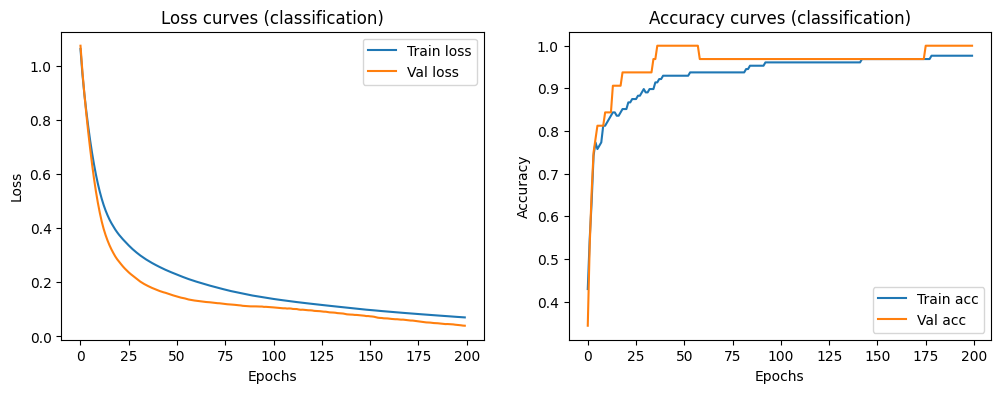

In [83]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history_cls.history['loss'], label='Train loss')
plt.plot(history_cls.history['val_loss'], label='Val loss')
plt.title('Loss curves (classification)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_cls.history['sparse_categorical_accuracy'], label='Train acc')
plt.plot(history_cls.history['val_sparse_categorical_accuracy'], label='Val acc')
plt.title('Accuracy curves (classification)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

Проводим оценку на тестовом наборе

In [84]:
test_loss, test_acc = model_cls.evaluate(X_test_cls, y_test_cls, verbose=0)
print(f"Классификация - Test accuracy: {test_acc:.4f}, Test loss: {test_loss:.4f}")

y_pred_cls = np.argmax(model_cls.predict(X_test_cls), axis=1)
print(f"Accuracy (sklearn): {accuracy_score(y_test_cls, y_pred_cls):.4f}")

Классификация - Test accuracy: 0.8500, Test loss: 0.6009
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Accuracy (sklearn): 0.8500


Модель классификации достигла точности 85% на тестовых данных. Это хороший результат. Потеря 0.6009 указывает на умеренную ошибку. С учётом небольшого объёма данных (200 обучающих примеров) точность можно считать удовлетворительной.

## Построение MLP для регрессии

Функция потерь – MSE. Выходной слой – 1 нейрон без активации

In [85]:
def create_regression_model(input_dim):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

model_reg = create_regression_model(X_train_reg.shape[1])
model_reg.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_27 (Dense)                │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,433 (9.50 KB)

 Trainable params: 2,433 (9.50 KB)

 Non-trainable params: 0 (0.00 B)

Проводим обучение

In [86]:
history_reg = model_reg.fit(
    X_train_reg, y_train_reg,
    validation_split=0.2,
    epochs=200,
    batch_size=16,
    callbacks=[EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)],
    verbose=1
)

Epoch 1/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 33192.0000 - mae: 164.4391 - val_loss: 23150.5449 - val_mae: 132.8611
Epoch 2/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 33021.4453 - mae: 163.9480 - val_loss: 23011.5879 - val_mae: 132.3826
Epoch 3/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 32833.4648 - mae: 163.4029 - val_loss: 22847.8750 - val_mae: 131.8133
Epoch 4/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 32595.4785 - mae: 162.7086 - val_loss: 22631.2051 - val_mae: 131.0513
Epoch 5/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 32281.1973 - mae: 161.7847 - val_loss: 22343.7500 - val_mae: 130.0295
Epoch 6/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 31864.6152 - mae: 160.5530 - val_loss: 21965.8340 - val_mae: 128.6728
Epoch 7/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 31320.0020 - mae: 158.9280 - val_loss: 21470.4004 - val_mae: 126.8751
Epoch 8/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 30611.1191 - mae: 156.7864 - val_loss

Визуализируем

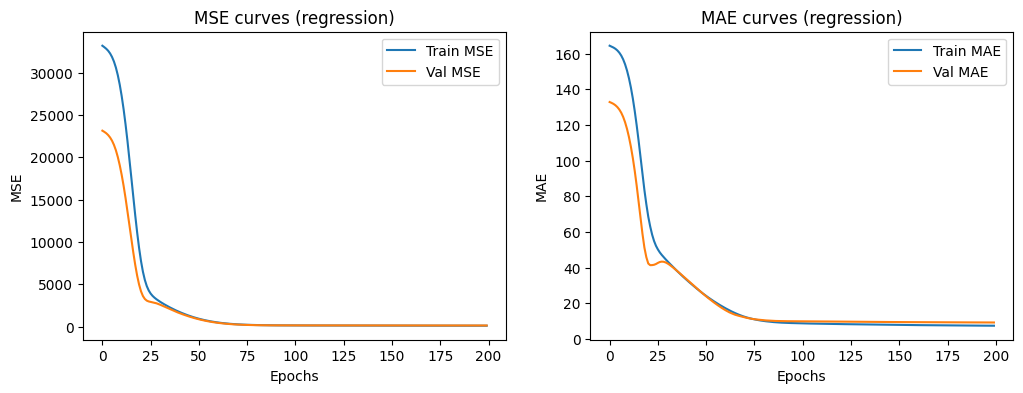

In [87]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history_reg.history['loss'], label='Train MSE')
plt.plot(history_reg.history['val_loss'], label='Val MSE')
plt.title('MSE curves (regression)')
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_reg.history['mae'], label='Train MAE')
plt.plot(history_reg.history['val_mae'], label='Val MAE')
plt.title('MAE curves (regression)')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()
plt.show()

Видим, что ошибка плавно снижается и к концу обучения выходит на плато.

In [88]:
test_mse, test_mae = model_reg.evaluate(X_test_reg, y_test_reg, verbose=0)
print(f"Регрессия - Test MSE: {test_mse:.4f}, Test MAE: {test_mae:.4f}")

y_pred_reg = model_reg.predict(X_test_reg).flatten()
print(f"MSE (sklearn): {mean_squared_error(y_test_reg, y_pred_reg):.4f}")
print(f"MAE (sklearn): {mean_absolute_error(y_test_reg, y_pred_reg):.4f}")

Регрессия - Test MSE: 134.0251, Test MAE: 9.4125
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
MSE (sklearn): 134.0252
MAE (sklearn): 9.4125


MAE составляет 9.41. Учитывая, что целевая переменная варьируется примерно от 75 до 322, ошибка около 9.4 – это примерно 3.8% от размаха, что можно считать неплохим результатом. MSE 134 также говорит о неплохой точности.

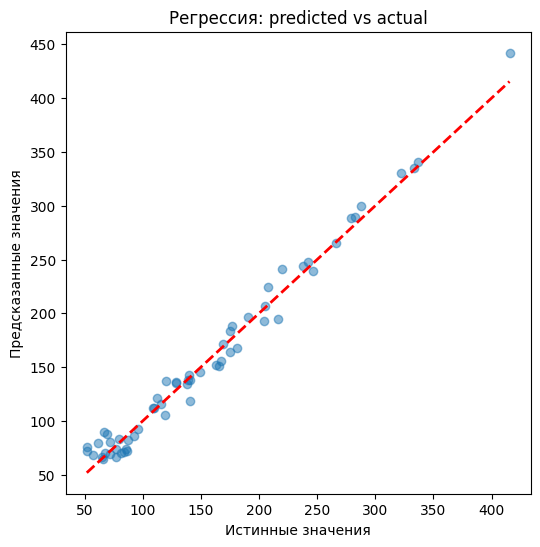

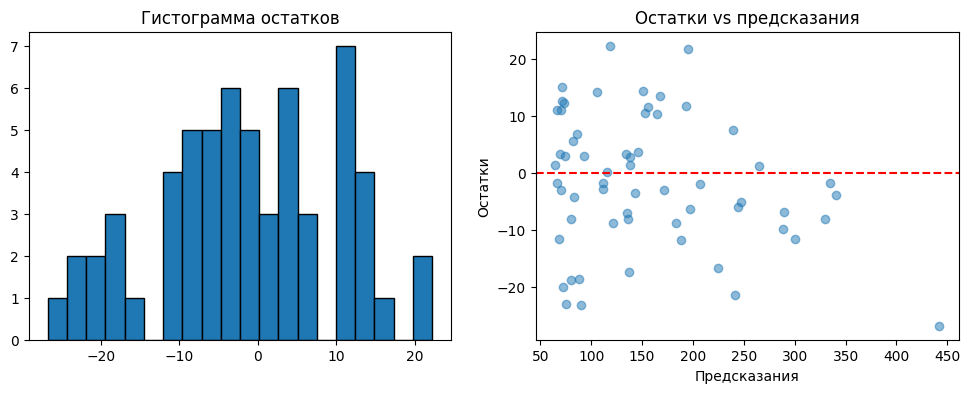

In [89]:
# Предсказанные vs истинные значения
plt.figure(figsize=(6,6))
plt.scatter(y_test_reg, y_pred_reg, alpha=0.5)
plt.plot([y_test_reg.min(), y_test_reg.max()],
         [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2)
plt.xlabel('Истинные значения')
plt.ylabel('Предсказанные значения')
plt.title('Регрессия: predicted vs actual')
plt.show()

# Проводим анализ остатков
residuals = y_test_reg - y_pred_reg
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.hist(residuals, bins=20, edgecolor='black')
plt.title('Гистограмма остатков')
plt.subplot(1,2,2)
plt.scatter(y_pred_reg, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Предсказания')
plt.ylabel('Остатки')
plt.title('Остатки vs предсказания')
plt.show()

Scatter-plot предсказанных vs истинных значений близок к диагонали, что подтверждает хорошее качество регрессии. Гистограмма остатков примерно симметрична относительно нуля, а график остатков vs предсказаний не показывает явных систематических отклонений.

## Работа с переобучением

In [90]:
reg_model = Sequential([
    Input(shape=(X_train_cls.shape[1],)),
    Dense(128, activation='relu', kernel_regularizer=L2(0.01)),
    Dropout(0.3),
    Dense(128, activation='relu', kernel_regularizer=L2(0.01)),
    Dropout(0.3),
    Dense(3, activation='softmax')
])
reg_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['sparse_categorical_accuracy'])

history_reg = reg_model.fit(X_train_cls, y_train_cls,
                            validation_data=(X_test_cls, y_test_cls),
                            epochs=200, batch_size=16, verbose=0)

In [91]:
overfit_model = Sequential([
    Input(shape=(X_train_cls.shape[1],)),
    Dense(128, activation='relu'),
    Dense(128, activation='relu'),
    Dense(3, activation='softmax')
])
overfit_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['sparse_categorical_accuracy'])

history_overfit = overfit_model.fit(X_train_cls, y_train_cls,
                                    validation_data=(X_test_cls, y_test_cls),
                                    epochs=200, batch_size=16, verbose=0)

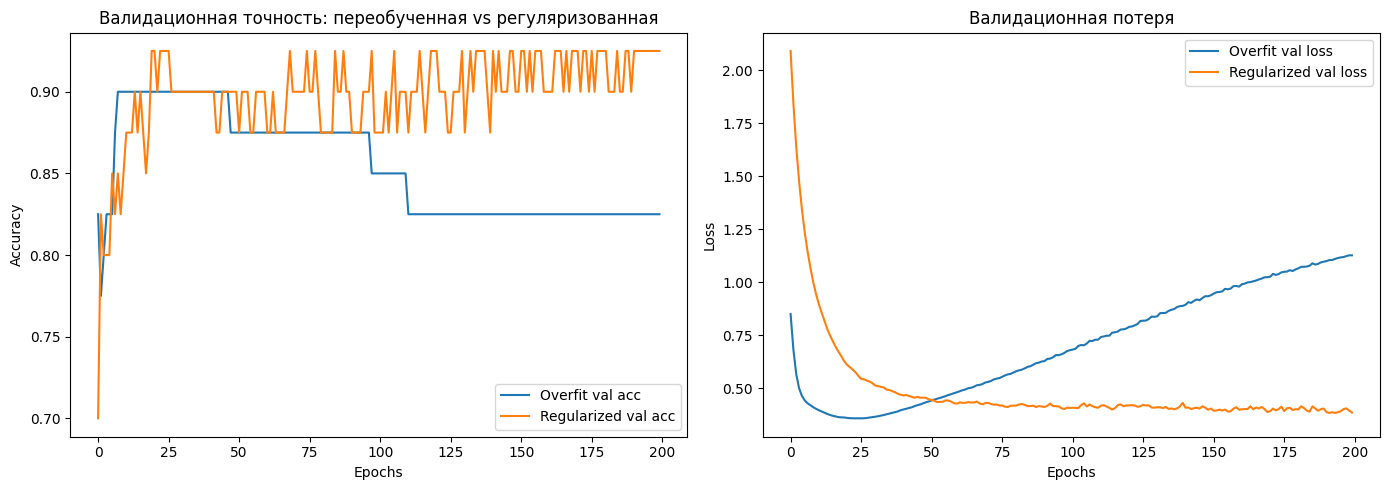

Переобученная модель - тестовая точность: 0.824999988079071
Регуляризованная модель - тестовая точность: 0.925000011920929


In [92]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(history_overfit.history['val_sparse_categorical_accuracy'], label='Overfit val acc')
plt.plot(history_reg.history['val_sparse_categorical_accuracy'], label='Regularized val acc')
plt.title('Валидационная точность: переобученная vs регуляризованная')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_overfit.history['val_loss'], label='Overfit val loss')
plt.plot(history_reg.history['val_loss'], label='Regularized val loss')
plt.title('Валидационная потеря')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

print("Переобученная модель - тестовая точность:",
      overfit_model.evaluate(X_test_cls, y_test_cls, verbose=0)[1])
print("Регуляризованная модель - тестовая точность:",
      reg_model.evaluate(X_test_cls, y_test_cls, verbose=0)[1])

переобученная модель имеет высокую тренировочную точность, но более низкую валидационную, тогда как регуляризованная модель демонстрирует стабильно высокую валидационную точность. Можем сказать, что мы подтвердили эффективность методов борьбы с переобучением.